# Figure 5 Compare Models


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/data"

multi_compare_exp = "2025_04_16_fig4_compare_intrxs_rs47.pkl"

binary_compare_exp ="2025_04_16_fig5_compare_to_binary_rs47.pkl"

In [34]:

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_filtered",
    "prev_viol_binary_itrx",
    "prev_viol_filtered_itrx",
]
LABELS = [
    "Baseline",
    "+ Binary\nViolation History",
    "+ Filtered\nViolation History",
    "+ Binary\nViolation History\n& Stim Intrxs",
    "+ Filtered\nViolation History\n& Stim Intrxs",
]
COLORS = [
    "gray",
    "#93c47d",
    "darkgreen",
    "orange",
    "#ce8641",
]

# B Compare Multi


In [35]:
mvcm = ModelVisualizerCompare(load_experiment(multi_compare_exp))


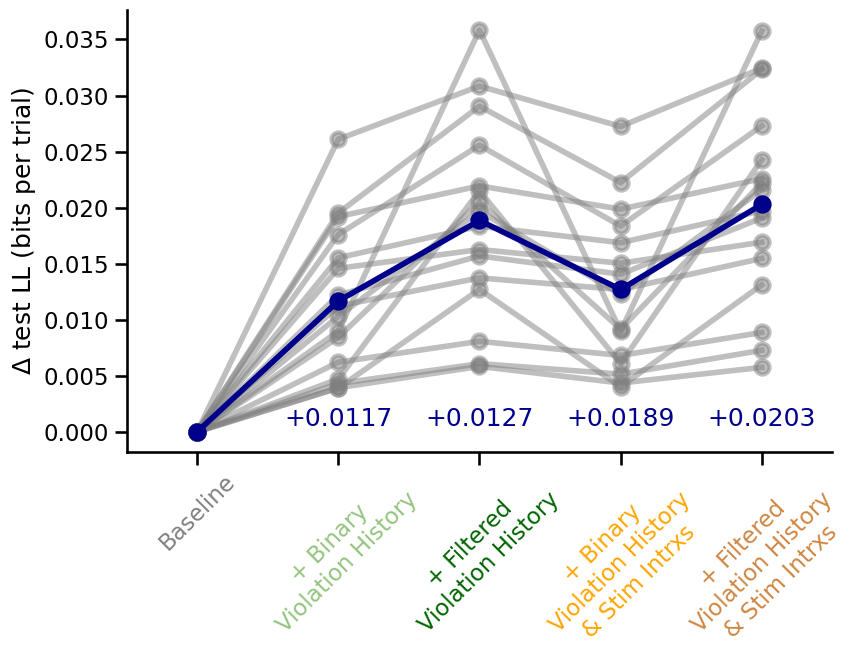

In [36]:
fig, ax = plt.subplots(figsize=(9,7
                                ))
sns.despine()
mvcm.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvcm.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
    annotate=True,
    y_annotate=0.0005,
    color_annotate=c.MODEL_COMPARE_COLOR,
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)
ax.legend().remove()
ax.set(xlabel="", title="")

# save fig
plt.tight_layout()
plt.savefig("figures/fig5_multi_compare_prev_viol_and_intrxs.png", dpi=300, bbox_inches="tight")

In [37]:
bpt = mvcm.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.775654,0.071471
prev_viol_binary,0.011669,0.006623
prev_viol_binary_itrx,0.012697,0.006916
prev_viol_filtered,0.018852,0.008682
prev_viol_filtered_itrx,0.020290,0.008969


## Base vs Intrx Filtered


In [38]:

mvcm.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1044: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1048: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2488.0641759895393}

In [39]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 3.191618687982257e+155,
 'log10_geometric_mean_ratio': 155.5040109993462}

> On average, each animal's test data is $3.19 x 10^{155}$ or $10^{155}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [40]:

mvcm.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 2.768265790233539e+176,
 'log10_overall_ratio': 176.4422077858173}

In [41]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 106570741274.93971,
 'log10_geometric_mean_ratio': 11.027637986613579}

> On average, each animal's test data is $1.06 x 10^{11}$ or $10^{11}$ times more likely under the previous violation filtered model


In [42]:
bpt = mvcm.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.775654,0.071471
prev_viol_binary,0.011669,0.006623
prev_viol_binary_itrx,0.012697,0.006916
prev_viol_filtered,0.018852,0.008682
prev_viol_filtered_itrx,0.020290,0.008969


## Base vs Intrx Filtered


In [43]:

mvcm.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1044: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1048: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2488.0641759895393}

In [44]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 3.191618687982257e+155,
 'log10_geometric_mean_ratio': 155.5040109993462}

> On average, each animal's test data is $3.19 x 10^{155}$ or $10^{155}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [45]:

mvcm.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 2.768265790233539e+176,
 'log10_overall_ratio': 176.4422077858173}

In [46]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 106570741274.93971,
 'log10_geometric_mean_ratio': 11.027637986613579}

> On average, each animal's test data is $1.06 x 10^{11}$ or $10^{11}$ times more likely under the previous violation filtered model


# D Compare Binary


In [47]:
mvcb = ModelVisualizerCompare(load_experiment(binary_compare_exp))

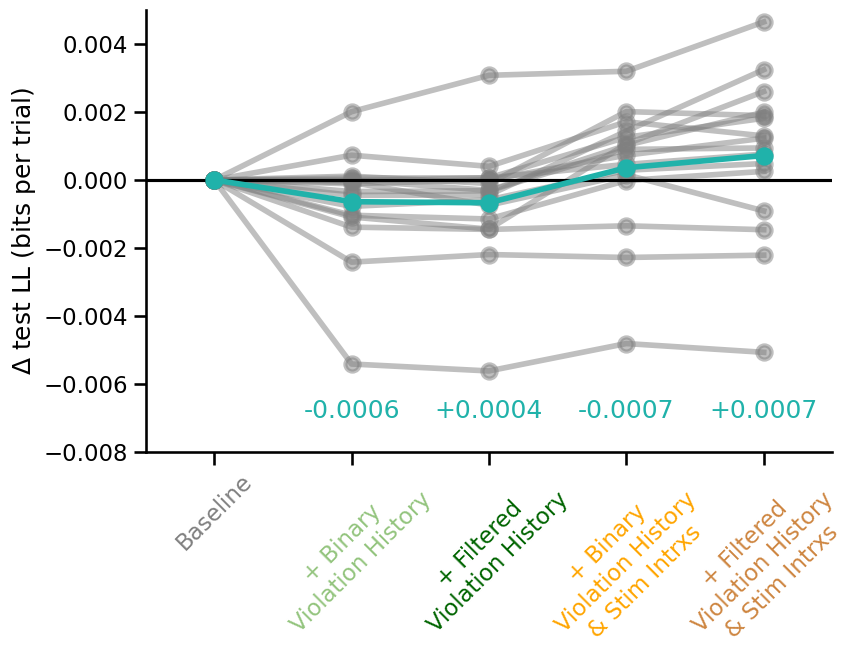

In [48]:
fig, ax = plt.subplots(figsize=(9,7
                                ))
sns.despine()
mvcb.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
ax.axhline(y=0, color="black")
mvcb.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.BINARY_MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
    annotate=True,
    y_annotate=-0.007,
    color_annotate=c.BINARY_MODEL_COMPARE_COLOR,
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)
ax.legend().remove()
ax.set(xlabel="", title="", ylim=(-0.008, 0.005))

# save fig
plt.tight_layout()
plt.savefig("figures/fig5_binary_compare_prev_viol_and_intrxs.png", dpi=300, bbox_inches="tight")

In [49]:
bpt = mvcb.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.368120,0.086600
prev_viol_binary,-0.000639,0.001599
prev_viol_binary_itrx,0.000360,0.001875
prev_viol_filtered,-0.000672,0.001744
prev_viol_filtered_itrx,0.000719,0.002309


## Base vs Intrx Filtered


In [50]:

mvcb.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 9.085837527858464e+95,
 'log10_overall_ratio': 95.9583649665326}

In [51]:

mvcb.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 994026.1518503844,
 'log10_geometric_mean_ratio': 5.9973978104082875}

> On average, each animal's test data is $10^{6}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [52]:

mvcb.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 3.212908505765073e+129,
 'log10_overall_ratio': 129.5068983582913}

In [53]:

mvcb.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 124217031.78435294,
 'log10_geometric_mean_ratio': 8.094181147393206}

> On average, each animal's test data is $10^{8}$ times more likely under the previous violation filtered model
